# One strait, two countries, one model

An end-to-end pass through omnisea in five steps: **discover** what exists around Juan de Fuca
Strait, **fetch** four agencies from two countries into one tree, **align** them onto one time
axis, **find and drop the correlated features**, fit a **predictive model** with a held-out
score, and end with the **citation** block for a methods section.

Everything below ran against the live APIs. Every number in the prose is the number the cell
above it printed.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import omnisea

# Third-party deprecations only. omnisea's own warnings stay on — they are how it tells you
# a join is about to be wrong.
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 150)
plt.rcParams["figure.figsize"] = (11, 3.4)

SITE = omnisea.Site(48.30, -123.53, "Juan de Fuca", radius_km=45)
WINDOW = ("2024-06-01", "2024-07-01")
print(f"omnisea {omnisea.__version__} — {len(omnisea.sources())} sources, "
      f"{len(omnisea.providers())} organizations")

omnisea 0.1.0 — 52 sources, 22 organizations


## 1. Discover — look before you download

The Canada–US boundary runs down the middle of this strait, so both countries' observing
systems answer one query. Nothing is downloaded yet; the catalogue shows what each source
holds and roughly how many rows it would cost.

In [2]:
cat = omnisea.discover(sites=SITE, time=WINDOW,
                      providers=["dfo_tides", "noaa_coops", "eccc_climate"])
print(f"{len(cat)} stations, ~{cat.n_rows_est:,} rows if fetched\n")
print(cat.describe().head(8).to_string(index=False))

37 stations, ~27,360 rows if fetched

      source station_id                       name  distance_km  n_rows_est                          variables
eccc_climate    1016640                 RACE ROCKS         0.25         720 air_pressure, air_temperature, de…
   dfo_tides      07080                 Pedder Bay         3.83         120 water_surface_height_above_refere…
   dfo_tides      07082               William Head         4.59         120 water_surface_height_above_refere…
   dfo_tides      07030                 Becher Bay         6.70         120 water_surface_height_above_refere…
   dfo_tides      07024                Sooke Basin        13.93         120 water_surface_height_above_refere…
eccc_climate    1012710          ESQUIMALT HARBOUR        16.13         720 air_pressure, air_temperature, de…
   dfo_tides      07110 Esquimalt Government  Hbr.        16.18         120 water_surface_height_above_refere…
   dfo_tides      07020                      Sooke        16.42         12

## Fetch the nearest station per source

Observations and predictions land in **separate branches** — a harmonic tide prediction and a
measurement look identical in a flat table and are not remotely the same thing. Note the two
countries side by side: DFO's Pedder Bay, NOAA's Port Angeles, ECCC's Race Rocks lightstation.

In [3]:
tree = cat.filter(nearest=1).fetch()
print(omnisea.describe(tree)[["node", "station_name", "n_time"]].to_string(index=False))

Data were retrieved with omnisea 0.1.0 on 2026-08-28T13:08:54+00:00 from 3 source(s) across 3 station(s), covering 2024-06-01 to 2024-07-01.

  Fisheries and Oceans Canada / Canadian Hydrographic Service — dfo_tides (1 station(s), 2024-06-01 to 2024-06-30): Pedder Bay (07080). Licence: Fisheries and Oceans Canada — Open Government Licence – Canada. Terms: https://open.canada.ca/en/open-government-licence-canada
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_climate (1 station(s), 2024-06-01 to 2024-07-01): RACE ROCKS (1016640). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc.github.io/open-data/licence/readme_en/
  NOAA Center for Operational Oceanographic Products and Services — noaa_coops (1 station(s), 2024-06-01 to 2024-07-01): Port Angeles (9444090). Licence: US Government work — public domain (NOAA CO-OPS). Terms: https://tidesandcurrents.noaa.gov/disclaimers.html
(saved at tree.attrs["c

## 2. Align everything onto one hourly axis

Six-minute US water levels, irregular predicted extrema from both countries, hourly Canadian
met — one call puts them on one grid, choosing each variable's resampling from its own CF
metadata. The choices are recorded, not guessed: read `attrs["omnisea_aggregation"]`.

In [4]:
X = omnisea.align(tree, freq="1h")
print(f"{X.shape[0]} hourly rows x {X.shape[1]} columns\n")
show = ["water_surface_height_above_reference_datum",
        "water_surface_height_above_reference_datum_at_extremum@9444090",
        "air_pressure", "wind_speed"]
for c in show:
    n_obs = X.attrs["omnisea_samples"][c]
    print(f"  {c}")
    print(f"      rule: {X.attrs['omnisea_aggregation'][c]}   (rests on {n_obs:,} observations)")

721 hourly rows x 12 columns

  water_surface_height_above_reference_datum
      rule: mean   (rests on 7,201 observations)
  water_surface_height_above_reference_datum_at_extremum@9444090
      rule: interpolate (upsampled)   (rests on 98 observations)
  air_pressure
      rule: mean   (rests on 721 observations)
  wind_speed
      rule: mean   (rests on 721 observations)


## 3. See the redundancy across the sources

A matrix assembled from many agencies is collinear by construction. `correlations()` shows
every pair that moves together, with `n` — the overlapping samples each `r` was computed on.

In [5]:
omnisea.correlations(X, threshold=0.85)

,feature_a,feature_b,r,n
0,water_surface_height_above_reference_datum_at_...,water_surface_height_above_reference_datum_at_...,0.954746,714
1,water_surface_height_above_reference_datum_at_...,water_surface_height_above_reference_datum,0.933954,714
2,water_surface_height_above_reference_datum_at_...,water_surface_height_above_reference_datum,0.869165,714


The top pair is the interesting one: **Canada's and the United States'
harmonic predictions of the same strait**, made by different agencies from different gauges,
correlate at r = 0.95. That is genuine redundancy — two modelled versions of one signal — and
exactly what `drop_correlated()` exists to prune.

One judgement call matters here: prune the **features only**. The response column must not go
into the pruning set — `keep=` would protect the response itself but evict every feature
correlated *with* it, which for a water-level model is the tide. So: drop the response out,
prune what remains.

In [6]:
RESPONSE = "water_surface_height_above_reference_datum"   # Port Angeles observed, hourly mean

features = omnisea.drop_correlated(X.drop(columns=[RESPONSE, "sigma"]), threshold=0.9)
print(f"{X.shape[1] - 2} candidate feature columns -> {features.shape[1]} kept\n")
for column, why in features.attrs["omnisea_dropped"].items():
    print(f"  dropped {column}")
    print(f"          {why}")

10 candidate feature columns -> 9 kept

  dropped water_surface_height_above_reference_datum_at_extremum@07080
          |r|=0.9547 with water_surface_height_above_reference_datum_at_extremum@9444090 over 714 samples; kept column rests on 98 observation(s)


The audit line does the explaining: of the two predictions it kept the one
resting on **more real observations** (98 predicted extrema against 76 over this window) —
counted before any resampling, so an interpolated column cannot win by manufacturing cells.

## 4. Fit a predictive model

Predict the **observed** hourly water level at Port Angeles (m above MLLW) from the surviving
cross-border features: the harmonic prediction, air pressure, and wind speed. Held-out split,
so the score is earned on hours the model never saw.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

FEATURES = ["water_surface_height_above_reference_datum_at_extremum@9444090",
            "air_pressure", "wind_speed"]
M = features[FEATURES].join(X[RESPONSE]).dropna()

X_train, X_test, y_train, y_test = train_test_split(
    M[FEATURES], M[RESPONSE], test_size=0.3, random_state=0)
model = LinearRegression().fit(X_train, y_train)
predicted = model.predict(X_test)

print(f"{len(M)} usable hours; trained on {len(X_train)}, scored on {len(X_test)} held out")
print(f"held-out R2  = {r2_score(y_test, predicted):.3f}")
print(f"held-out MAE = {mean_absolute_error(y_test, predicted):.3f} m\n")
coefs = pd.Series(model.coef_, index=FEATURES).round(4)
print(coefs.to_frame("coefficient").to_string())

714 usable hours; trained on 499, scored on 215 held out
held-out R2  = 0.848
held-out MAE = 0.214 m

                                                                coefficient
water_surface_height_above_reference_datum_at_extremum@9444090       0.9920
air_pressure                                                        -0.0320
wind_speed                                                           0.0021


Two coefficients carry physics, which is the sanity check on the whole
pipeline:

* the **harmonic prediction enters at ~1.0** — a prediction of the same quantity in the same
  units should map one-to-one onto the observation, and it does;
* **air pressure enters negative** — the inverse-barometer effect (high pressure pushes the
  sea surface down), attenuated here because the harmonic prediction already carries most of
  the signal.

A wrong join — a timezone slip, a datum mix-up, a unit change — would have bent both.

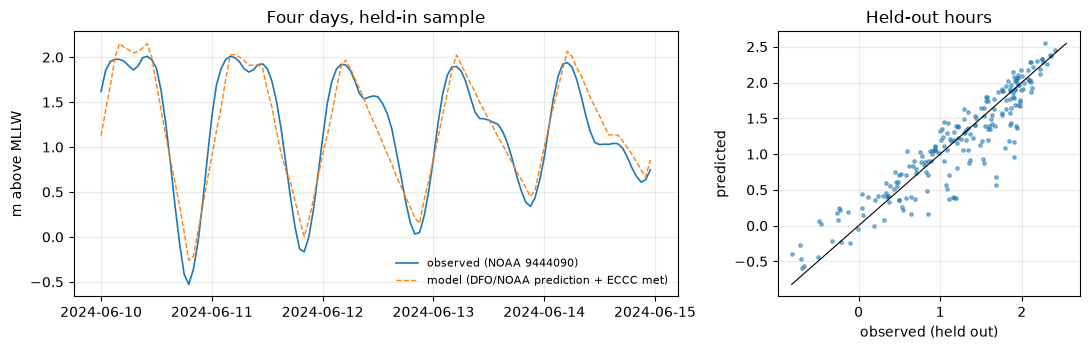

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6),
                               gridspec_kw={"width_ratios": [2, 1]})
slice_ = M.loc["2024-06-10":"2024-06-14"]
ax1.plot(slice_.index, slice_[RESPONSE], lw=1.2, label="observed (NOAA 9444090)")
ax1.plot(slice_.index, model.predict(slice_[FEATURES]), lw=1.0, ls="--",
         label="model (DFO/NOAA prediction + ECCC met)")
ax1.set_ylabel("m above MLLW"); ax1.legend(frameon=False, fontsize=8)
ax1.set_title("Four days, held-in sample"); ax1.grid(alpha=0.25)
ax2.scatter(y_test, predicted, s=6, alpha=0.5)
lim = [min(y_test.min(), predicted.min()), max(y_test.max(), predicted.max())]
ax2.plot(lim, lim, lw=0.8, color="k")
ax2.set_xlabel("observed (held out)"); ax2.set_ylabel("predicted")
ax2.set_title("Held-out hours"); ax2.grid(alpha=0.25)
fig.tight_layout()

## 5. What do I cite?

Attribution comes out of the result, not out of memory — both countries' licences, the
stations by name, and anything that went wrong during the fetch.

In [9]:
print(omnisea.citation(tree))

Data were retrieved with omnisea 0.1.0 on 2026-08-28T13:08:54+00:00 from 3 source(s) across 3 station(s), covering 2024-06-01 to 2024-07-01.

  Fisheries and Oceans Canada / Canadian Hydrographic Service — dfo_tides (1 station(s), 2024-06-01 to 2024-06-30): Pedder Bay (07080). Licence: Fisheries and Oceans Canada — Open Government Licence – Canada. Terms: https://open.canada.ca/en/open-government-licence-canada
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_climate (1 station(s), 2024-06-01 to 2024-07-01): RACE ROCKS (1016640). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc.github.io/open-data/licence/readme_en/
  NOAA Center for Operational Oceanographic Products and Services — noaa_coops (1 station(s), 2024-06-01 to 2024-07-01): Port Angeles (9444090). Licence: US Government work — public domain (NOAA CO-OPS). Terms: https://tidesandcurrents.noaa.gov/disclaimers.html


## Recap

* One `discover()` + one `fetch()`: **four series from three agencies in two countries**, in
  one tree, observations and predictions never sharing a node.
* One `align(freq="1h")`: six-minute, irregular-event and hourly data on one axis, every
  resampling choice recorded with the observation count behind it.
* `correlations()` surfaced the cross-border redundancy; `drop_correlated()` pruned it and
  wrote down why — pruning **features only**, so the response's own drivers survive.
* A held-out model whose coefficients carry the physics, which is the end-to-end check that
  the times, units and datums all lined up.
* `citation(tree)` for the methods section.

For deeper walkthroughs: `bamfield.ipynb` (the full tour), `juan_de_fuca.ipynb` (six sampling
grains, unit systems across the border), `strait_of_georgia.ipynb` (model vs instruments),
`prince_rupert.ipynb` and `calvert_island.ipynb`.